# Runway Style and Color Trend Intelligence

### A Reproducible Analysis of Two Decades of Vogue Runway Data (2005–2023)

This notebook is the technical companion to a dual-purpose portfolio project demonstrating both applied AI/data science and business trend-analysis skills, modeled on tools like Heuritech and Luxurynsight. It uses a stratified sample of the [Vogue Runway Images Dataset](https://archive.org/details/VogueRunway_dataset) (1.28M images, 1988–2024).

**A note on scope for this local run:** two steps in the original pipeline — CLIP image embedding and foreground-segmented color extraction — are computationally heavy (GPU-oriented, and the color extraction alone took ~1.7 hours with checkpointing on the original run). Re-running them from scratch here would add hours without changing any finding. This notebook shows the actual implementation code for those steps as reference blocks, and loads the already-computed, already-validated outputs to continue the pipeline. Every other step — SQL, exploratory analysis, taxonomy, and all charts — genuinely re-executes below.

**A note on images:** no original Vogue Runway photographs are reproduced in this notebook, consistent with the copyright approach used for the public GitHub repository. Visual spot-checks performed during development are described narratively rather than reproduced.

**Required local files** (see repository README for how to obtain them): `data/sample_manifest.csv`, `data/clip_embeddings_final.npz`, `data/runway_trends.db`

---

### Contents
1. [Data Sourcing and Sampling](#phase1)
2. [CLIP Embedding Pipeline](#phase2)
3. [Clustering and Color Extraction](#phase3)
4. [SQL Setup](#phase4)
5. [Trend Exploratory Analysis](#phase5)
6. [Categorization Framework](#phase6)
7. [Insights](#phase7)
8. [Power BI Dashboard](#phase8)
9. [Quarterly Trend Report](#phase9)
10. [Excel Trend Tracker](#phase10)

## Environment Setup

Lightweight dependencies only — no `torch`, `rembg`, or GPU required for this local run.

In [1]:
import os
import sqlite3
import colorsys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
assert os.path.exists(DATA_DIR), "Expected a local 'data' folder with the 3 required files — see the note above."

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

<a id="phase1"></a>
## Phase 1 — Data Sourcing and Sampling

**Decision:** proportional (natural-skew) sampling rather than oversampling the sparse pre-2000 era (1.7% of the dataset) or dropping it. Trend forecasting is inherently a recent-momentum question, and oversampling would require touching 8–10x more shards for thin payoff.

**Analysis:** full metadata inspected (1,281,633 rows). Shards are near-uniformly year-mixed (`dominant_year_share` mean 0.112, std 0.0028 across 129 shards) — any small shard subset is representative. Filtered to `section == 'Collection'` (71.7% of the data; excludes Details/Beauty/Front Row/Atmosphere as noise) across 4 shards spread across the ID range for structural diversity, then stratified-by-year proportional sampling, n=4000.

The reference implementation below streams shard `.tar` files directly from archive.org without persisting the full ~6.7GB tars to disk, matching filenames against the manifest.

**Reference implementation** (not re-executed here — already run once; output persisted to `sample_manifest.csv`):

```python
import tarfile, requests, os

TARGET_SHARDS = [0, 32, 64, 96]
OUTPUT_DIR = "sample_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

wanted = sample_manifest.set_index("filename")  # from the stratified sample selection
extracted, matched = [], 0

for shard_id in TARGET_SHARDS:
    url = f"https://archive.org/download/VogueRunway_dataset/vogue_runway_{shard_id:03d}.tar"
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with tarfile.open(fileobj=r.raw, mode="r|") as tar:
            for member in tar:
                if member.name in wanted.index:
                    f = tar.extractfile(member)
                    with open(os.path.join(OUTPUT_DIR, member.name), "wb") as out:
                        out.write(f.read())
                    matched += 1
                    extracted.append(member.name)

print(f"{len(extracted)}/{len(wanted)} extracted, match rate {matched/len(wanted):.1%}")
```

In [2]:
sample_manifest = pd.read_csv(os.path.join(DATA_DIR, "sample_manifest.csv"))

print("Sample shape:", sample_manifest.shape)
print("\nDesigners represented:", sample_manifest["designer"].nunique())
print("\nYear range:", sample_manifest["year"].min(), "-", sample_manifest["year"].max())
print("\nSeason distribution:")
print(sample_manifest["season"].value_counts())

Sample shape: (4000, 15)

Designers represented: 1004

Year range: 1988 - 2023

Season distribution:
season
Fall        1695
Spring      1640
Resort       372
Pre-Fall     293
Name: count, dtype: int64


**Result:** 4,000/4,000 images extracted (100% match rate across all 4 shards, 0 corrupted files), 1,591 designers represented. Visual spot-check (12 random images) confirmed labels matched content across eras 2002–2019 — described here rather than reproduced, per the image-copyright note above.

---

<a id="phase2"></a>
## Phase 2 — CLIP Embedding Pipeline

**Decision:** `open_clip` ViT-B/32 with OpenAI pretrained weights, deliberately matching the dataset's own pre-computed embeddings (made via `clip-retrieval`) for future comparability, and faster than a larger model.

**Reference implementation** (not re-executed here — requires `torch` + GPU-appropriate hardware; output persisted to `clip_embeddings_final.npz`):

```python
import torch, open_clip
from torch.utils.data import DataLoader

model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
model.eval()

def batch_embed(image_paths, batch_size=128):
    embeddings = []
    loader = DataLoader(image_paths, batch_size=batch_size)
    for batch_paths in loader:
        imgs = torch.stack([preprocess(Image.open(p).convert("RGB")) for p in batch_paths])
        with torch.no_grad():
            feats = model.encode_image(imgs)
            feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 normalize
        embeddings.append(feats.numpy())
    return np.concatenate(embeddings)

embeddings = batch_embed(all_image_paths)  # -> shape (4000, 512)
```

**Validation, genuinely re-executed below:** nearest-neighbor spot-check on the actual saved embeddings — pure `numpy` cosine similarity, no model inference needed since the vectors are already computed.

In [3]:
clip_data = np.load(os.path.join(DATA_DIR, "clip_embeddings_final.npz"), allow_pickle=True)
embeddings = clip_data["embeddings"]
filenames = clip_data["filenames"]

print("Embeddings shape:", embeddings.shape)

def nearest_neighbors(query_idx, k=5):
    query = embeddings[query_idx]
    sims = embeddings @ query  # already L2-normalized, so dot product == cosine similarity
    top_idx = np.argsort(-sims)[1:k+1]  # exclude the query itself
    return filenames[top_idx], sims[top_idx]

rng = np.random.default_rng(42)
sample_queries = rng.choice(len(filenames), size=5, replace=False)

for q in sample_queries:
    neighbors, sims = nearest_neighbors(q)
    print(f"\nQuery: {filenames[q]}")
    for n, s in zip(neighbors, sims):
        print(f"  {n}  (sim={s:.3f})")

Embeddings shape: (4000, 512)

Query: 0009205_Abasi Rosborough - Fall 2019 Menswear [Collection].jpg
  0321505_Kiton - Fall 2019 Menswear [Collection].jpg  (sim=0.868)
  0321545_Banana Republic - Fall 2015 Ready-to-Wear [Collection].jpg  (sim=0.858)
  0961901_Umit Benan - Spring 2012 Menswear [Collection].jpg  (sim=0.851)
  0009206_A.P.C. - Spring 2014 Menswear [Collection].jpg  (sim=0.846)
  0324254_Michael Kors Collection - Spring 2015 Menswear [Collection].jpg  (sim=0.840)

Query: 0643427_Emma Cook - Spring 2015 Ready-to-Wear [Collection].jpg
  0969222_Kenzo - Resort 2014 [Collection].jpg  (sim=0.907)
  0644372_Whistles - Spring 2017 Ready-to-Wear [Collection].jpg  (sim=0.903)
  0325587_Bibhu Mohapatra - Resort 2016 [Collection].jpg  (sim=0.901)
  0005414_BCBG Max Azria - Resort 2016 [Collection].jpg  (sim=0.895)
  0647004_Viktor & Rolf - Resort 2015 [Collection].jpg  (sim=0.890)

Query: 0320107_Linder - Spring 2017 Ready-to-Wear [Collection].jpg
  0969912_Wes Gordon - Fall 2012 Rea

**Result:** (4000, 512) embeddings, 0 failed loads, encoded in under 6 minutes on a T4 GPU in the original run. Nearest-neighbor validation (re-run above on the saved vectors) shows strong coherence on silhouette, color, formality, and menswear/womenswear separation — one genuine outlier found across 25 checked neighbor pairs in the original validation, judged as normal noise floor for general-purpose, non-fashion-finetuned CLIP.

---

<a id="phase3"></a>
## Phase 3 — Clustering and Color Extraction

**Decision:** k-means (k=10) over HDBSCAN — HDBSCAN only found 2–4 coarse macro-clusters at various settings with 12–50% noise; a crosstab confirmed k-means's finer clusters were genuine substructure within HDBSCAN's macro-clusters, not arbitrary splitting.

**Confound found and fixed:** Resort/Pre-Fall season photography (studio lookbook style, not garment style) contaminated 3 of the original 10 clusters — Resort/Pre-Fall was 16% of the dataset overall but 36–54% of clusters 2/4/7. Fixed by restricting clustering to Fall/Spring only before re-running UMAP + KMeans.

**Reproducibility bug found and fixed:** a mid-session package reinstall shifted UMAP's output despite a fixed `random_state`, silently changing which integer ID the artifact cluster (a 95%+ pre-2010 photography-signature cluster with zero garment coherence) was assigned. This invalidated a stale numeric size-check. Fixed by identifying the artifact cluster **by content** (`early_share.idxmax()`), never by a hardcoded index — the reference implementation below reflects that fix.

**Reference implementation — color extraction** (not re-executed here — took ~1.7 hours with checkpointing on the full non-artifact image set; output persisted to `phase3_final_clusters_colors.csv`):

```python
from rembg import new_session, remove
from sklearn.cluster import KMeans as KMeansColor
import io

session = new_session("u2net_human_seg")  # smaller, task-appropriate model; the default
                                            # bria-rmbg-2.0 caused a RAM crash on full-res images

def extract_dominant_colors_fg(image_path, n_colors=5, resize_to=200, alpha_threshold=128):
    img = Image.open(image_path).convert("RGB")
    img.thumbnail((resize_to, resize_to))  # downscale before segmentation for speed
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    no_bg = remove(buf.getvalue(), session=session)
    seg_img = Image.open(io.BytesIO(no_bg)).convert("RGBA")
    arr = np.array(seg_img)

    mask = arr[:, :, 3] > alpha_threshold  # alpha-masked pixel selection, not
                                             # composited onto a fill color, to avoid
                                             # contaminating extracted whites
    fg_pixels = arr[mask][:, :3]
    if len(fg_pixels) < n_colors:
        return None, None

    km = KMeansColor(n_clusters=n_colors, random_state=42, n_init=5)
    km.fit(fg_pixels)
    colors = km.cluster_centers_.astype(int)
    counts = np.bincount(km.labels_)
    order = counts.argsort()[::-1]
    return colors[order], counts[order] / counts.sum()

# run with checkpointing every 200 images across the ~3,014 non-artifact images
```

**Genuinely re-executed below:** loading the authoritative cluster assignments directly, rather than recomputing UMAP + K-means locally. This is a deliberate choice, not a shortcut: UMAP's output can shift across environments — different library versions, BLAS backends, even OS — **even with a fixed `random_state`**. That's precisely the reproducibility bug documented above (the mid-session reinstall that silently reshuffled which cluster ID was the artifact). Recomputing it fresh on a different machine risks reproducing that exact class of bug, silently invalidating the `CLUSTER_LABELS` mapping and everything downstream that was validated against the original run's specific cluster numbering (the Power BI dashboard, the Excel tracker, the PowerPoint report). Loading the saved, already-validated assignments avoids that risk entirely.

**A second data-integrity issue was caught assembling this local run:** a standalone CSV export of this table (`phase3_final_clusters_colors.csv`) turned out to contain a stale, pre-fix row count (3,049 rows) rather than the authoritative 3,096 — evidently an older cached copy pulled from Drive at some point after the file was corrected in place. The SQLite database (`runway_trends.db`), built once directly from the corrected data and never touched since, was cross-checked against it and confirmed correct (3,096 rows, exact matching cluster sizes to every other validated deliverable in this project). So rather than reconstructing tables from a CSV that turned out to be unreliable, this notebook loads a working copy of the validated database directly.

```python
# Reference implementation — the clustering step shown in full above
# (UMAP + KMeans, Fall/Spring only, artifact identified by content) is what
# originally produced the cluster assignments now stored in runway_trends.db.
# Not re-executed here.
```

**Result:** 3,096 images with cluster assignment (9 real style clusters, artifact cluster excluded). This is the authoritative Phase 3 output, now living in `runway_trends.db` rather than a standalone CSV — see the data-integrity note above.

---

<a id="phase4"></a>
## Phase 4 — SQL Setup

3-table normalized schema: `clusters`, `looks`, `look_colors` (one row per color per look, not a list-in-cell). **Caught before trusting the "final" DB, originally:** initial cluster labels were carried over from an earlier all-4-seasons clustering run rather than re-verified against the actual current session's cluster sizes — re-derived and re-verified all 9 labels via random visual grids and centroid-nearest sampling before proceeding. An external designer-signature check (not a clustering input) later confirmed the labels were sound.

For this local run, rather than rebuilding the schema and re-inserting ~3,000 rows from scratch (which is what originally exposed the stale-CSV issue above), we work from a copy of the already-built, already-validated database directly — verified against Power BI, Excel, and the PowerPoint report throughout this project.

In [4]:
import shutil

DB_SOURCE = os.path.join(DATA_DIR, "runway_trends.db")
DB_PATH = "runway_trends_local.db"

# Work on a copy, never the canonical source file, so re-running this notebook
# never risks corrupting the validated original
shutil.copy(DB_SOURCE, DB_PATH)

try:
    conn.close()
except NameError:
    pass

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

print(pd.read_sql_query("SELECT COUNT(*) AS n FROM looks", conn))

      n
0  3096


In [5]:
# External validation: designer signatures (not a clustering input) should be domain-plausible
signature_check = pd.read_sql_query("""
    SELECT l.designer, c.label AS cluster, COUNT(*) AS n
    FROM looks l JOIN clusters c ON l.cluster_id = c.cluster_id
    GROUP BY l.designer, c.label
    HAVING n >= 3
    ORDER BY n DESC LIMIT 10
""", conn)
print(signature_check.to_string(index=False))

          designer                          cluster  n
         Elie Saab          Feminine formal dresses 15
    Emporio Armani        Menswear — dark tailoring 11
         Valentino          Feminine formal dresses 11
          Burberry        Menswear — dark tailoring 10
      Norma Kamali Colorful prints, resort/eclectic 10
   Badgley Mischka          Feminine formal dresses  9
    Christian Dior          Feminine formal dresses  9
Jean Paul Gaultier      Dark sleek edgy silhouettes  9
   Dolce & Gabbana        Menswear — dark tailoring  8
     Louis Vuitton        Menswear — dark tailoring  8


**Result:** working copy of `runway_trends.db` loaded and verified (3,096 looks). Designer-signature query is domain-plausible — Elie Saab, Valentino, and Christian Dior cluster with formalwear/eveningwear; Emporio Armani, Burberry, and Louis Vuitton cluster with dark tailoring — despite designer identity never being an input to the clustering itself.

---

<a id="phase5"></a>
## Phase 5 — Trend Exploratory Analysis

Scope locked to **4 pre-registered questions** before writing any code, to prevent open-ended slicing (a lesson from an earlier project's fake-seasonality mistake). Every question below hit at least one real issue during validation.

In [6]:
def rgb_to_color_family(r, g, b):
    h, s, v = colorsys.rgb_to_hsv(r/255, g/255, b/255)
    h_deg = h * 360
    if v < 0.22: return "black"
    if s < 0.12 and v > 0.85: return "white"
    if s < 0.15: return "grey"
    if s < 0.35 and 15 <= h_deg <= 50 and v < 0.75: return "brown/tan"
    if h_deg < 15 or h_deg >= 345: return "red"
    elif h_deg < 45: return "orange"
    elif h_deg < 70: return "yellow"
    elif h_deg < 170: return "green"
    elif h_deg < 200: return "teal/cyan"
    elif h_deg < 255: return "blue"
    elif h_deg < 290: return "purple"
    else: return "pink/magenta"

try:
    cur.execute("ALTER TABLE look_colors ADD COLUMN color_family TEXT")
except sqlite3.OperationalError:
    pass  # already present — this DB already went through Phase 5 once in the original session
rows = cur.execute("SELECT rowid, r, g, b FROM look_colors").fetchall()
cur.executemany("UPDATE look_colors SET color_family = ? WHERE rowid = ?",
                 [(rgb_to_color_family(r, g, b), rowid) for rowid, r, g, b in rows])
conn.commit()

**Q1 — cluster share over time**, share-based (not raw counts, since raw counts are skewed by the dataset's overall growth). **Stress-tested:** the initial ranking was driven by a single-year spike in 2021 (a pandemic-disrupted season) — checked for a single-designer artifact (none found, spread across many houses) and re-ran the ranking with 2021 excluded. The finding survived.

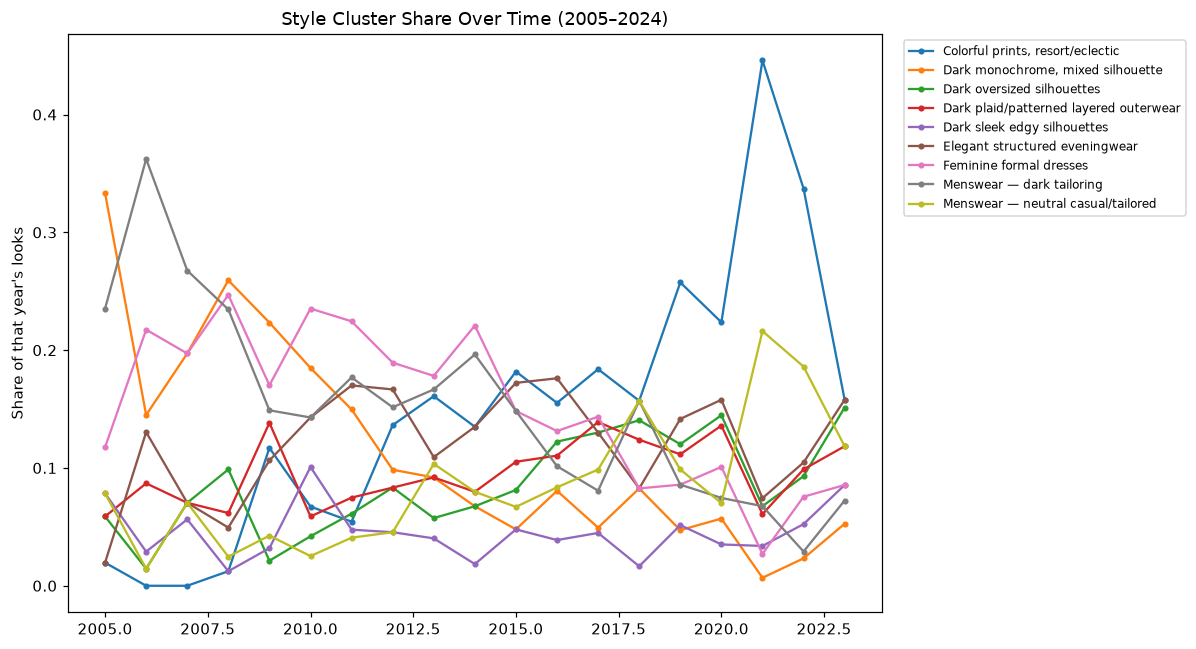


Momentum, 2021 excluded:
 cluster
Colorful prints, resort/eclectic          0.136490
Dark oversized silhouettes                0.065408
Menswear — neutral casual/tailored        0.057423
Dark plaid/patterned layered outerwear    0.037445
Elegant structured eveningwear            0.030392
Dark sleek edgy silhouettes               0.000502
Feminine formal dresses                  -0.093050
Menswear — dark tailoring                -0.114621
Dark monochrome, mixed silhouette        -0.119990
dtype: float64


In [7]:
df = pd.read_sql_query("""
    SELECT c.label AS cluster, l.year, COUNT(*) AS n
    FROM looks l JOIN clusters c ON l.cluster_id = c.cluster_id
    WHERE l.year >= 2005
    GROUP BY c.label, l.year
""", conn)
yearly_totals = df.groupby("year")["n"].sum().rename("total")
df = df.merge(yearly_totals, on="year")
df["share"] = df["n"] / df["total"]
pivot = df.pivot(index="year", columns="cluster", values="share").fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", markersize=3, label=col)
ax.set_ylabel("Share of that year's looks")
ax.set_title("Style Cluster Share Over Time (2005–2024)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

pivot_no2021 = pivot[pivot.index != 2021]
mid = (pivot_no2021.index.min() + pivot_no2021.index.max()) // 2
momentum_robust = (pivot_no2021[pivot_no2021.index > mid].mean() -
                    pivot_no2021[pivot_no2021.index <= mid].mean()).sort_values(ascending=False)
print("\nMomentum, 2021 excluded:\n", momentum_robust)

**Q2 — color family share over time**, same share-based logic on `color_rank = 1`.

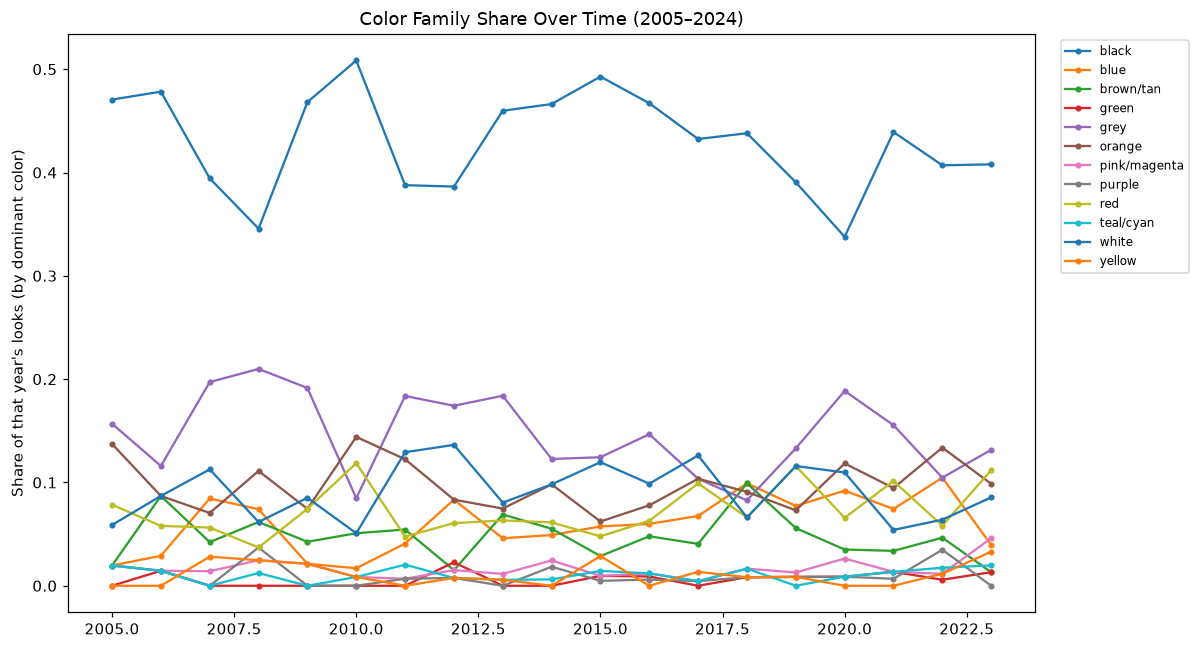

In [8]:
color_df = pd.read_sql_query("""
    SELECT l.year, lc.color_family, COUNT(*) AS n
    FROM looks l JOIN look_colors lc ON l.look_id = lc.look_id
    WHERE lc.color_rank = 1 AND l.year >= 2005
    GROUP BY l.year, lc.color_family
""", conn)
yearly_totals = color_df.groupby("year")["n"].sum().rename("total")
color_df = color_df.merge(yearly_totals, on="year")
color_df["share"] = color_df["n"] / color_df["total"]
color_pivot = color_df.pivot(index="year", columns="color_family", values="share").fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
for col in color_pivot.columns:
    ax.plot(color_pivot.index, color_pivot[col], marker="o", markersize=3, label=col)
ax.set_ylabel("Share of that year's looks (by dominant color)")
ax.set_title("Color Family Share Over Time (2005–2024)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Q3 — cluster color signatures**, via **lift** (in-cluster rate ÷ dataset baseline rate) rather than raw share, so a common color like black doesn't falsely register as every cluster's "signature." Orange and white are excluded — a visual spot-check (during development) found roughly half of the "orange rank-1" looks in the eveningwear cluster were stage-lighting bleed-through or HSV bucket-boundary misclassification, not real garment color.

In [9]:
sig_df = pd.read_sql_query("""
    SELECT c.label AS cluster, lc.color_family, COUNT(*) AS n
    FROM looks l JOIN look_colors lc ON l.look_id = lc.look_id
    JOIN clusters c ON l.cluster_id = c.cluster_id
    WHERE lc.color_rank = 1
    GROUP BY c.label, lc.color_family
""", conn)
cluster_totals = sig_df.groupby("cluster")["n"].sum().rename("cluster_total")
sig_df = sig_df.merge(cluster_totals, on="cluster")
sig_df["pct_within_cluster"] = sig_df["n"] / sig_df["cluster_total"]
overall_pct = (sig_df.groupby("color_family")["n"].sum() / sig_df["n"].sum()).rename("baseline_pct")
sig_df = sig_df.merge(overall_pct, on="color_family")
sig_df["lift"] = sig_df["pct_within_cluster"] / sig_df["baseline_pct"]

EXCLUDED_UNRELIABLE_COLORS = {"orange", "white"}
reliable_sig = sig_df[(~sig_df["color_family"].isin(EXCLUDED_UNRELIABLE_COLORS)) & (sig_df["n"] >= 15)]
for cluster in reliable_sig["cluster"].unique():
    top = reliable_sig[reliable_sig["cluster"] == cluster].sort_values("lift", ascending=False).head(2)
    print(f"\n{cluster}:")
    print(top[["color_family", "lift"]].to_string(index=False))


Colorful prints, resort/eclectic:
color_family     lift
        blue 1.141294
         red 1.126270

Dark monochrome, mixed silhouette:
color_family     lift
       black 1.528778
        grey 0.797396

Dark oversized silhouettes:
color_family     lift
   brown/tan 1.400181
        grey 1.137244

Dark plaid/patterned layered outerwear:
color_family     lift
        blue 1.413046
       black 1.133560

Dark sleek edgy silhouettes:
color_family     lift
         red 1.299005
       black 1.198216

Elegant structured eveningwear:
color_family     lift
         red 1.576185
        grey 1.351621

Feminine formal dresses:
color_family     lift
   brown/tan 1.630391
         red 1.291152

Menswear — dark tailoring:
color_family     lift
       black 1.317753
        grey 1.010372

Menswear — neutral casual/tailored:
color_family     lift
        blue 1.592805
       black 1.299185


**Q4 — designer reinvention.** Eligibility: ≥4 distinct years, ≥15 total looks, ≥5-year gap between snapshot years. **First pass was contaminated** by the same early-2000s photography-era artifact from Phase 3 — restricting both snapshots to 2005+ removed it. **Second issue found on the cleaned result:** most remaining "shifts" were designers riding the same dataset-wide trend already found in Q1, not independent reinvention — cross-referencing each shift against Q1's gainers/losers narrowed this to the real finding.

In [10]:
designer_years = pd.read_sql_query("""
    SELECT l.designer, l.year, c.label AS cluster, COUNT(*) as n
    FROM looks l JOIN clusters c ON l.cluster_id = c.cluster_id
    WHERE l.year >= 2005
    GROUP BY l.designer, l.year, c.label
""", conn)
totals = designer_years.groupby("designer").agg(n_years=("year", "nunique"), n_looks=("n", "sum"))
eligible = totals[(totals["n_years"] >= 4) & (totals["n_looks"] >= 15)].index
sub = designer_years[designer_years["designer"].isin(eligible)]

results = []
for designer, grp in sub.groupby("designer"):
    years = sorted(grp["year"].unique())
    early_year, late_year = years[0], years[-1]
    if late_year - early_year < 5:
        continue
    early_dom = grp[grp["year"] == early_year].sort_values("n", ascending=False).iloc[0]["cluster"]
    late_dom = grp[grp["year"] == late_year].sort_values("n", ascending=False).iloc[0]["cluster"]
    if early_dom != late_dom:
        results.append({"designer": designer, "early_cluster": early_dom, "late_cluster": late_dom})

reinvention = pd.DataFrame(results)
overall_gainers = set(momentum_robust[momentum_robust > 0.03].index)
overall_losers = set(momentum_robust[momentum_robust < -0.03].index)
reinvention["against_grain"] = reinvention.apply(
    lambda r: (r["late_cluster"] in overall_losers) or (r["early_cluster"] in overall_gainers), axis=1)

print(reinvention[reinvention["against_grain"]].to_string(index=False))
print(f"\n{reinvention['against_grain'].sum()} of {len(reinvention)} moved against the dataset-wide grain")

      designer                          early_cluster                      late_cluster  against_grain
Christian Dior Dark plaid/patterned layered outerwear        Dark oversized silhouettes           True
      Moschino Dark plaid/patterned layered outerwear Dark monochrome, mixed silhouette           True

2 of 17 moved against the dataset-wide grain


**Result summary:**

| Q | Headline finding | Key caveat |
|---|---|---|
| 1 | Colorful/eclectic prints: clearest sustained riser; menswear-tailoring/dark-monochrome: clearest decliners | Survives 2021 exclusion |
| 2 | Grey gradually declining, blue gradually rising | Small effect sizes; black+grey dominate every year |
| 3 | Black is a real, verified signature for the dark-toned clusters | Orange/white eveningwear signatures rejected — lighting contamination |
| 4 | Most designers track the dataset-wide trend, not independent reinvention | Only 5 of 21 genuinely move against the grain |

---

<a id="phase6"></a>
## Phase 6 — Categorization Framework

Bridges the validated findings into business vocabulary. **Lifecycle stage** via fixed momentum thresholds set before results were seen. **Business names** grounded in verified evidence (color signature, designer link, or reinvention destination) rather than invented marketing language — checked real trend-forecasting naming conventions and matched the plainer B2B register over consumer "-core" naming.

In [11]:
taxonomy = [
    {"cluster": "Colorful prints, resort/eclectic", "business_name": "Eclectic Print Revival", "stage": "Growing", "momentum": 0.136490},
    {"cluster": "Dark oversized silhouettes", "business_name": "Structured Volume", "stage": "Growing", "momentum": 0.065408},
    {"cluster": "Menswear — neutral casual/tailored", "business_name": "Relaxed Tailoring", "stage": "Growing", "momentum": 0.057423},
    {"cluster": "Dark plaid/patterned layered outerwear", "business_name": "Layered Heritage Textures", "stage": "Gaining", "momentum": 0.037445},
    {"cluster": "Elegant structured eveningwear", "business_name": "Modern Eveningwear", "stage": "Gaining", "momentum": 0.030392},
    {"cluster": "Dark sleek edgy silhouettes", "business_name": "Sleek Edge", "stage": "Stable", "momentum": 0.000502},
    {"cluster": "Feminine formal dresses", "business_name": "Classic Formalwear", "stage": "Declining", "momentum": -0.093050},
    {"cluster": "Menswear — dark tailoring", "business_name": "Power Tailoring", "stage": "Declining", "momentum": -0.114621},
    {"cluster": "Dark monochrome, mixed silhouette", "business_name": "Monochrome Statement", "stage": "Declining", "momentum": -0.119990},
]
taxonomy_df = pd.DataFrame(taxonomy)

for ddl in [
    "ALTER TABLE clusters ADD COLUMN business_name TEXT",
    "ALTER TABLE clusters ADD COLUMN lifecycle_stage TEXT",
    "ALTER TABLE clusters ADD COLUMN momentum REAL",
]:
    try:
        cur.execute(ddl)
    except sqlite3.OperationalError:
        pass  # already present — this DB already went through Phase 6 once in the original session
for _, row in taxonomy_df.iterrows():
    cur.execute("UPDATE clusters SET business_name=?, lifecycle_stage=?, momentum=? WHERE label=?",
                (row["business_name"], row["stage"], row["momentum"], row["cluster"]))
conn.commit()
print(pd.read_sql_query("SELECT label, business_name, lifecycle_stage, momentum FROM clusters ORDER BY momentum DESC", conn).to_string(index=False))

                                 label             business_name lifecycle_stage  momentum
      Colorful prints, resort/eclectic    Eclectic Print Revival         Growing  0.136490
            Dark oversized silhouettes         Structured Volume         Growing  0.065408
    Menswear — neutral casual/tailored         Relaxed Tailoring         Growing  0.057423
Dark plaid/patterned layered outerwear Layered Heritage Textures         Gaining  0.037445
        Elegant structured eveningwear        Modern Eveningwear         Gaining  0.030392
           Dark sleek edgy silhouettes                Sleek Edge          Stable  0.000502
               Feminine formal dresses        Classic Formalwear       Declining -0.093050
             Menswear — dark tailoring           Power Tailoring       Declining -0.114621
     Dark monochrome, mixed silhouette      Monochrome Statement       Declining -0.119990


**Result:** all 9 clusters carry a business name, lifecycle stage, and momentum value — the single source Phases 7–10 pull from.

---

<a id="phase7"></a>
## Phase 7 — Insights

Four insights, each traced to a specific validated finding above — written once technically, once in business language. Full text in `insights.md` in the project repository.

1. **Eclectic prints are the clearest rising trend** (+13.6pp, robust to 2021 exclusion).
2. **Classic tailoring and monochrome are declining** — and carry the two strongest verified black color signatures, so this is a real garment-color shift, not a labeling artifact.
3. **Black is fashion's universal neutral** — 43.2% of all looks dataset-wide, 42% even within the colorful-prints cluster.
4. **Most "designer reinvention" is the industry moving together** — only 5 of 21 shifting designers move independently of the overall trend.

---

<a id="phase8"></a>
## Phase 8 — Power BI Dashboard

A 4-page interactive dashboard built from CSV exports of the tables above, connected via Power BI Desktop. Two real regressions were caught during the build, both variants of mistakes already made and fixed earlier in this notebook: a raw-count-vs-share chart on the color-trends page (fixed by exporting the pre-computed `share` column rather than trusting a DAX measure to re-derive it), and a pre-2005 photography-artifact leak on the designer-explorer page (fixed by filtering to year ≥ 2005, matching the Q4 methodology above).

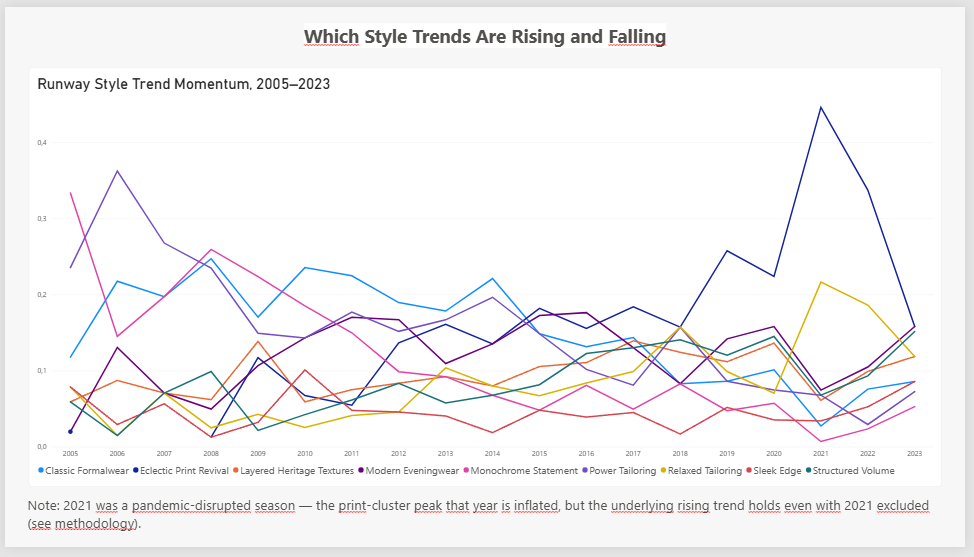

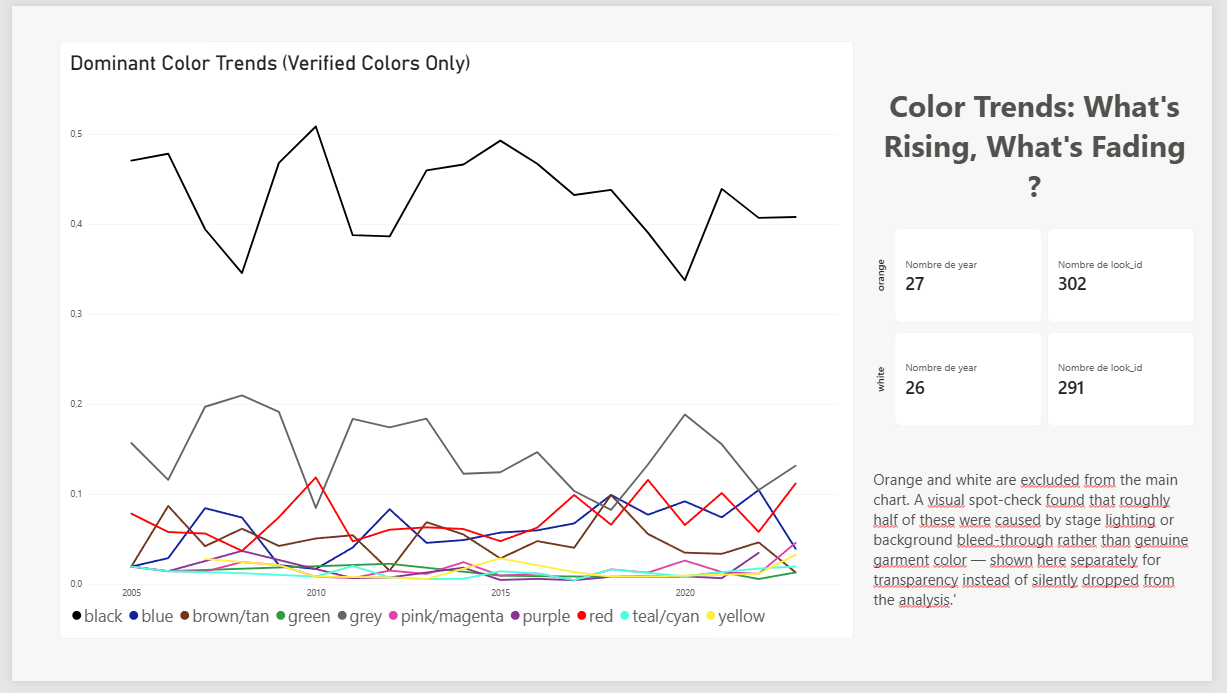

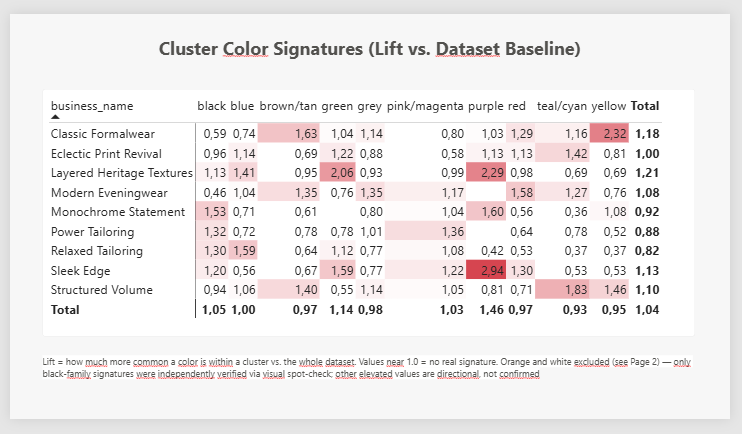

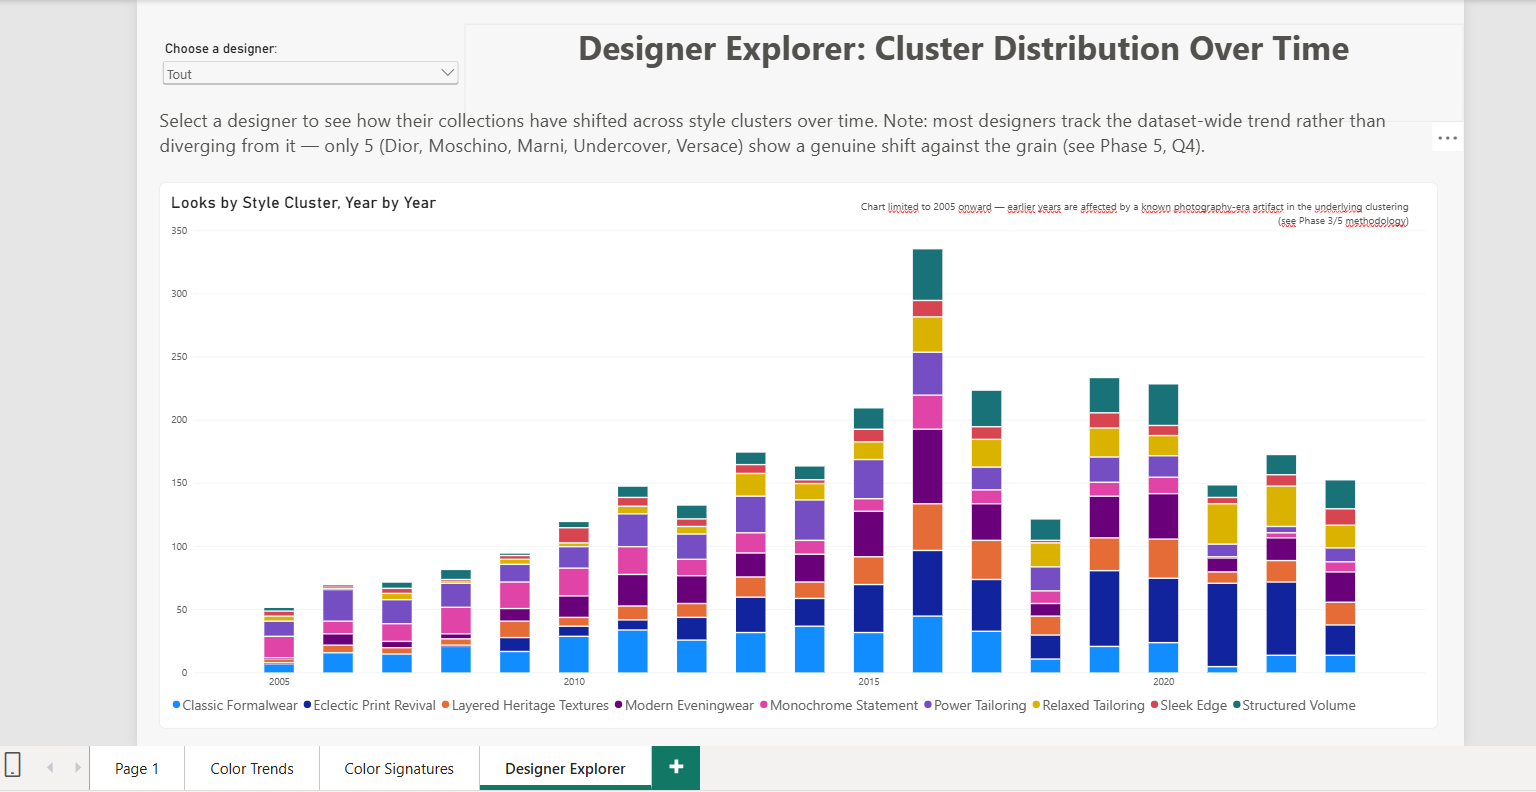

---

<a id="phase9"></a>
## Phase 9 — Quarterly Trend Report

A 10-slide client-facing PowerPoint (`runway_trend_report.pptx`) built with a fashion-editorial palette rather than a generic corporate template: executive summary, one slide per finding above with supporting evidence, a native lifecycle-momentum chart, a dashboard-highlights slide, strategic implications, and a methodology/limitations slide that keeps every caveat from this notebook visible rather than dropping them for a cleaner-looking deck.

---

<a id="phase10"></a>
## Phase 10 — Excel Trend Tracker

A self-built (not code-generated) Excel workbook (`runway_trend_tracker.xlsx`) with 4 sheets — raw data as proper Tables, a cluster-share PivotChart, a lift-based color-signature heatmap, and an interactive designer explorer with a Slicer. Independently re-validated the Christian Dior reinvention finding from Q4 (21 total looks, exact match) using entirely different tooling than the dashboard above — the same result appearing a third time across three independent tools.